# Wakefield

In [1]:
import sys
sys.path.append("..")
import matplotlib
%matplotlib widget
import pprint
pp = pprint.PrettyPrinter(indent=4)
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities

cavs = Cavities(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations')

# define geometry parameters
n_cells = 2
midcell = [62.22, 66.13, 30.22, 23.11, 72, 93.5, 171.20]  # <- A, B, a, b, Ri, L, Req
endcell_l = [62.58, 57.54, 17.21, 12, 80, 93.795, 171.20]
endcell_r = [62.58, 57.54, 17.21, 12, 80, 93.795, 171.20]

# create cavity
tesla = EllipticalCavity(n_cells, midcell, endcell_l,endcell_r, beampipe='both')
cavs.add_cavity([tesla], names=['C3795'], plot_labels=['C3795'])

wakefield_config = {
    'bunch_length': 25,
    'wakelength': 2,
    'processes': 1,
    'rerun': True,
}
cavs.run_wakefield(wakefield_config)
# pp.pprint(cavs.wakefield_qois)

result True C:\Users\Soske\Documents\git_projects\cavsim2d_simulations cavities
DONE:: Project C:\Users\Soske\Documents\git_projects\cavsim2d_simulations created already exists. 
	Set `overwrite=True` to overwrite.


In [2]:
# cavs[0].plot_animate_wakefield(save=False)

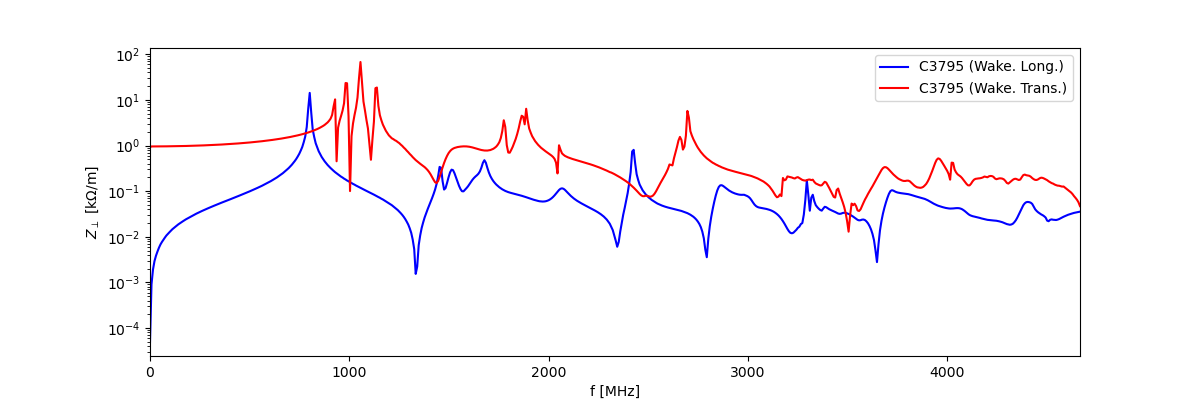

In [3]:
ax = cavs.plot('ZL', c='b')
ax = cavs.plot('Zt', ax, c='r')
ax.set_yscale('log')

# Wakefield + Operating Points

In [ ]:
import sys
sys.path.append("..")
import pprint
pp = pprint.PrettyPrinter(indent=4)
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities

cavs = Cavities(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations\new')

# define geometry parameters
n_cells = 2
midcell = [42, 42, 12, 19, 35, 57.7, 103.353]  # <- A, B, a, b, Ri, L, Req
endcell_l = [40.34, 40.34, 10, 13.5, 39, 55.716, 103.353]
endcell_r = [42, 42, 9, 12.8, 39, 56.815, 103.353]

# create cavity
tesla = EllipticalCavity(n_cells, midcell, endcell_l,endcell_r, beampipe='none')
cavs.add_cavity([tesla], names=['TESLA'], plot_labels=['TESLA'])

op_points = {
            "Z": {
                "freq [MHz]": 400.79,  # Operating frequency
                "E [GeV]": 45.6,  # <- Beam energy
                "I0 [mA]": 1280,  # <- Beam current
                "V [GV]": 0.12,  # <- Total voltage
                "Eacc [MV/m]": 5.72,  # <- Accelerating field
                "nu_s []": 0.0370,  # <- Synchrotron oscillation tune
                "alpha_p [1e-5]": 2.85,  # <- Momentum compaction factor
                "tau_z [ms]": 354.91,  # <- Longitudinal damping time
                "tau_xy [ms]": 709.82,  # <- Transverse damping time
                "f_rev [kHz]": 3.07,  # <- Revolution frequency
                "beta_xy [m]": 56,  # <- Beta function
                "N_c []": 56,  # <- Number of cavities
                "T [K]": 4.5,  # <- Operating tempereature
                "sigma_SR [mm]": 4.32,  # <- Bunch length
                "sigma_BS [mm]": 15.2,  # <- Bunch length
                "Nb [1e11]": 2.76  # <- Bunch population
            }
}

wakefield_config = {
    'bunch_length': 25,
    'wakelength': 50,
    'processes': 2,
    'rerun': True,
    'operating_points': op_points,
}
cavs.run_wakefield(wakefield_config)
pp.pprint(cavs.wakefield_qois)

In [ ]:
cavs.plot_compare_hom_bar('Z_SR_4.32mm')

# Wakefield + Operating Points + UQ

In [ ]:
import sys
sys.path.append("..")
import pprint
pp = pprint.PrettyPrinter(indent=4)
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities

cavs = Cavities(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations\new')

# define geometry parameters
n_cells = 2
midcell = [42, 42, 12, 19, 35, 57.7, 103.353]  # <- A, B, a, b, Ri, L, Req
endcell_l = [40.34, 40.34, 10, 13.5, 39, 55.716, 103.353]
endcell_r = [42, 42, 9, 12.8, 39, 56.815, 103.353]

# create cavity
tesla = EllipticalCavity(n_cells, midcell, endcell_l,endcell_r, beampipe='none')
cavs.add_cavity([tesla], names=['TESLA'], plot_labels=['TESLA'])

op_points = {
            "Z": {
                "freq [MHz]": 400.79,  # Operating frequency
                "E [GeV]": 45.6,  # <- Beam energy
                "I0 [mA]": 1280,  # <- Beam current
                "V [GV]": 0.12,  # <- Total voltage
                "Eacc [MV/m]": 5.72,  # <- Accelerating field
                "nu_s []": 0.0370,  # <- Synchrotron oscillation tune
                "alpha_p [1e-5]": 2.85,  # <- Momentum compaction factor
                "tau_z [ms]": 354.91,  # <- Longitudinal damping time
                "tau_xy [ms]": 709.82,  # <- Transverse damping time
                "f_rev [kHz]": 3.07,  # <- Revolution frequency
                "beta_xy [m]": 56,  # <- Beta function
                "N_c []": 56,  # <- Number of cavities
                "T [K]": 4.5,  # <- Operating tempereature
                "sigma_SR [mm]": 4.32,  # <- Bunch length
                "sigma_BS [mm]": 15.2,  # <- Bunch length
                "Nb [1e11]": 2.76  # <- Bunch population
            }
}

wakefield_config = {
    'bunch_length': 25,
    'wakelength': 50,
    'processes': 2,
    'rerun': True,
    'operating_points': op_points,
    'uq_config': {
        'variables': ['A'],
        'objectives': [["ZL", [1, 2, 5]], ["ZT", [2, 3, 4]]],
        'delta': [0.05],
        'processes': 4,
        'distribution': 'gaussian',
        # 'method': ['QMC', 'LHS', 1000],
        # 'method': ['QMC', 'Sobol', 1000],
        # 'method': ['Qudrature', 'Gaussian', 1000],
        'method': ['Quadrature', 'Stroud3'],
        # 'method': ['Quadrature', 'Stroud5'],
        # 'gaussian': ['Quadrature', 'Gaussian'],
        # 'from file': ['<file path>', columns],
        'cell_type': 'mid-cell',
        'cell complexity': 'simplecell'
        }
}
cavs.run_wakefield(wakefield_config)
pp.pprint(cavs.wakefield_qois)

In [ ]:
cavs.plot_compare_hom_bar('Z_SR_4.32mm')

# Wakefield (OP) + UQ (+OP)

In [ ]:
import sys
sys.path.append("..")
import pprint
pp = pprint.PrettyPrinter(indent=4)
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities

cavs = Cavities(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations\new')

# define geometry parameters
n_cells = 2
midcell = [42, 42, 12, 19, 35, 57.7, 103.353]  # <- A, B, a, b, Ri, L, Req
endcell_l = [40.34, 40.34, 10, 13.5, 39, 55.716, 103.353]
endcell_r = [42, 42, 9, 12.8, 39, 56.815, 103.353]

# create cavity
tesla = EllipticalCavity(n_cells, midcell, endcell_l,endcell_r, beampipe='none')
cavs.add_cavity([tesla], names=['TESLA'], plot_labels=['TESLA'])

shape_space = {'reentrant': 
                   {'IC': [53.58, 36.58, 8.08, 9.84, 35, 57.7, 98.27],
                    'OC': [53.58, 36.58, 8.08, 9.84, 35, 57.7, 98.27],
                    'OC_R': [53.58, 36.58, 8.08, 9.84, 35, 57.7, 98.27]
                    }
               }

# create cavity
shape = shape_space['reentrant']
reentrant = EllipticalCavity(n_cells, shape['IC'], shape['OC'], shape['OC_R'], beampipe='both')
cavs.add_cavity([reentrant], names=['Reentrant'], plot_labels=['Re-entrant'])

op_points = {
            "Z": {
                "freq [MHz]": 400.79,  # Operating frequency
                "E [GeV]": 45.6,  # <- Beam energy
                "I0 [mA]": 1280,  # <- Beam current
                "V [GV]": 0.12,  # <- Total voltage
                "Eacc [MV/m]": 5.72,  # <- Accelerating field
                "nu_s []": 0.0370,  # <- Synchrotron oscillation tune
                "alpha_p [1e-5]": 2.85,  # <- Momentum compaction factor
                "tau_z [ms]": 354.91,  # <- Longitudinal damping time
                "tau_xy [ms]": 709.82,  # <- Transverse damping time
                "f_rev [kHz]": 3.07,  # <- Revolution frequency
                "beta_xy [m]": 56,  # <- Beta function
                "N_c []": 56,  # <- Number of cavities
                "T [K]": 4.5,  # <- Operating tempereature
                "sigma_SR [mm]": 4.32,  # <- Bunch length
                "sigma_BS [mm]": 15.2,  # <- Bunch length
                "Nb [1e11]": 2.76  # <- Bunch population
            }
}

wakefield_config = {
    'bunch_length': 25,
    'wakelength': 50,
    'processes': 2,
    'rerun': False,
    'operating_points': op_points,
    'uq_config': {
        'variables': ['A', 'B'],
        'objectives': [["ZL", [1, 2, 5]], ["ZT", [2, 3, 4]], 'k_FM [V/pC]', '|k_loss| [V/pC]', '|k_kick| [V/pC/m]', 'P_HOM [kW]'],
        'delta': [0.05, 0.05],
        'processes': 4,
        'method': ['Stroud3'],
        'cell_type': 'mid-cell',
        'cell complexity': 'simplecell',
        'operating_points': op_points
        }
}
cavs.run_wakefield(wakefield_config)
pp.pprint(cavs.wakefield_qois)

In [ ]:
pp.pprint(cavs.uq_hom_results)

In [ ]:
ax = cavs.plot_compare_wakefield('Z_SR_4.32mm', kind='scatter', uq=True)

# delete

In [ ]:
# import sys
# sys.path.append("..")
# import matplotlib
# %matplotlib widget
# import pprint
# pp = pprint.PrettyPrinter(indent=4)
# from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities
# import numpy as np
# import sys
# import os
# import json
#
# # load shape space
# with open(r'D:\Dropbox\CavityDesignHub\PhD_Thesis/Cavities/cavities.json') as f:
#     shape_space = json.load(f)
#
# c3794_shape = shape_space['C3794']
# fccuros_shape = shape_space['FCCUROS']
# cepcv2_shape = shape_space['CEPCv2']
#
# # create cavities
# c3794 = EllipticalCavity(2, c3794_shape['IC'], c3794_shape['OC'], c3794_shape['OC_R'], beampipe='both', color='#4b8f63')
# c3794v2 = EllipticalCavity(2, 0.5*np.array(c3794_shape['IC']), 0.5*np.array(c3794_shape['OC']), 0.5*np.array(c3794_shape['OC_R']), beampipe='both', color='#6a7bbf')
# fccuros = EllipticalCavity(4, fccuros_shape['IC'], fccuros_shape['OC'], fccuros_shape['OC_R'], beampipe='both', color='#fc6d2d')
#
# c3795_shape = shape_space['C3795']
# c3795v2_shape = shape_space['C3795v2']
# fccuros5_shape = shape_space['FCC_UROS5']
# cepc_shape = shape_space['CEPCv2']
#
# # create cavities
# c3795 = EllipticalCavity(5, c3795_shape['IC'], c3795_shape['OC'], c3795_shape['OC_R'], beampipe='both', color='#4b8f63')
# c3795v2 = EllipticalCavity(5, c3795v2_shape['IC'], c3795v2_shape['OC'], c3795v2_shape['OC_R'], beampipe='both', color='#6a7bbf')
# fccuros5 = EllipticalCavity(5, fccuros5_shape['IC'], fccuros5_shape['OC'], fccuros5_shape['OC_R'], beampipe='both', color='#fc6d2d')
# cepcv2 = EllipticalCavity(2, cepc_shape['IC'], cepc_shape['OC'], cepc_shape['OC_R'], beampipe=cepc_shape['BP'], cell_parameterisation=cepc_shape['CELL TYPE'], color='#e567a7')
#
#
# cavs = Cavities()
# cavs.save(project_folder='D:\Dropbox\CavityDesignHub\MuCol_Study\SimulationData\ConsoleTest')
#
# cavs.add_cavity([c3795, c3795v2, fccuros5, c3794, c3794v2, cepcv2, fccuros], ['C3795', 'C3795v2', 'FCCUROS5', 'C3794', 'C3794v2', 'CEPCv2', 'FCCUROS'], ['C3795', 'C3795v2', 'FCCUROS5', 'C3794', 'C3794v2', 'CEPCv2', 'FCCUROS'])
#
# wakefield_config = {
#     'bunch_length': 25,
#     'wakelength': 200,
#     'MT': 19,
#     'processes': 7,
#     'rerun': True,
#     'DDR_SIG': 0.05,
#     'DDZ_SIG': 0.05
#     # 'save_fields': {
#     #     'nshot': 40,
#     # }
# }
# cavs.run_wakefield(wakefield_config)
# pp.pprint(cavs.wakefield_qois)